EXERCICE 1 : ACP sur un portefeuille d'assurance auto
=======================================================
Objectif : Réaliser une ACP sur les variables de tarification
pour comprendre la structure du portefeuille et identifier
les principaux axes de variabilité.

Ce que vous allez apprendre :
- Préparer les données pour l'ACP (scaling)
- Choisir le nombre de composantes (elbow, Kaiser)
- Interpréter les composantes principales
- Tracer un cercle des corrélations

Pré-requis : M03_F01, Bloc 1 de ce module
Temps estimé : 15 minutes

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 1. CHARGEMENT ET PRÉPARATION DES DONNÉES

In [2]:
# =============================================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# =============================================================
print("=" * 60)
print("EXERCICE 1 : ACP sur un portefeuille d'assurance")
print("=" * 60)

df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")

# On utilise les variables numériques continues
features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density', 'Exposure']
X = df[features].astype(float)

print(f"Dimensions : {X.shape[0]} assurés, {X.shape[1]} variables")
print(f"\nStatistiques descriptives :")
print(X.describe().round(2))

EXERCICE 1 : ACP sur un portefeuille d'assurance
Dimensions : 678013 assurés, 5 variables

Statistiques descriptives :
         DrivAge  BonusMalus     VehAge    Density   Exposure
count  678013.00   678013.00  678013.00  678013.00  678013.00
mean       45.50       59.76       7.04    1792.42       0.53
std        14.14       15.64       5.67    3958.65       0.36
min        18.00       50.00       0.00       1.00       0.00
25%        34.00       50.00       2.00      92.00       0.18
50%        44.00       50.00       6.00     393.00       0.49
75%        55.00       64.00      11.00    1658.00       0.99
max       100.00      230.00     100.00   27000.00       2.01


## 2. STANDARDISATION

In [3]:
# =============================================================
# 2. STANDARDISATION
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : Standardisation")
print("=" * 60)

# TODO : Standardiser les données avec StandardScaler
# Pourquoi est-ce INDISPENSABLE avant une ACP ?
# (Indice : comparer les ordres de grandeur de Density vs Exposure)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TODO : Vérifier que la moyenne de chaque variable est ~0 et l'écart-type ~1
print("Moyennes après scaling :", np.round(X_scaled.mean(axis=0), 6))
print("Écarts-types après scaling :", np.round(X_scaled.std(axis=0), 4))
print("\n→ Sans scaling, Density (ordre 10^4) dominerait toutes les composantes")
print("  car l'ACP maximise la variance. Le scaling met toutes les variables")
print("  sur un pied d'égalité.")



PARTIE 1 : Standardisation
Moyennes après scaling : [-0.  0. -0. -0. -0.]
Écarts-types après scaling : [1. 1. 1. 1. 1.]

→ Sans scaling, Density (ordre 10^4) dominerait toutes les composantes
  car l'ACP maximise la variance. Le scaling met toutes les variables
  sur un pied d'égalité.


## 3. ACP — CHOIX DU NOMBRE DE COMPOSANTES

## TODO : Réaliser une ACP avec TOUTES les composantes (n_components=None)


PARTIE 2 : Choix du nombre de composantes

Variance expliquée par composante :
  PC1 : 0.3198 (0.3198 cumulé)
  PC2 : 0.2369 (0.5567 cumulé)
  PC3 : 0.1889 (0.7456 cumulé)
  PC4 : 0.1519 (0.8974 cumulé)
  PC5 : 0.1026 (1.0000 cumulé)


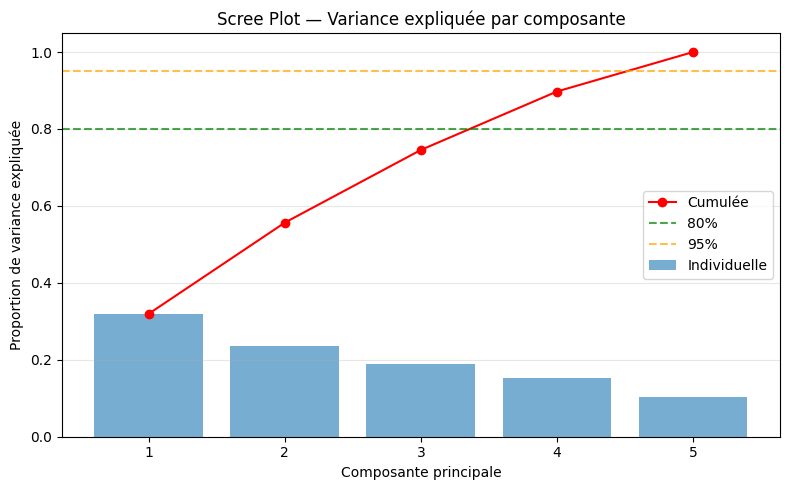


Critère de Kaiser (eigenvalue > 1) :
  PC1 : eigenvalue = 1.5990  → ✓ GARDER
  PC2 : eigenvalue = 1.1843  → ✓ GARDER
  PC3 : eigenvalue = 0.9445  → ✗ ÉLIMINER
  PC4 : eigenvalue = 0.7593  → ✗ ÉLIMINER
  PC5 : eigenvalue = 0.5128  → ✗ ÉLIMINER

→ Kaiser retient 2 composantes
→ 95% de variance atteint avec 5 composantes


In [4]:
# =============================================================
# 3. ACP — CHOIX DU NOMBRE DE COMPOSANTES
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Choix du nombre de composantes")
print("=" * 60)

# TODO : Réaliser une ACP avec TOUTES les composantes (n_components=None)
# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)




# TODO : Afficher la variance expliquée par chaque composante
# Indice : pca.explained_variance_ratio_
print("\nVariance expliquée par composante :")
for i, (var, cumvar) in enumerate(zip(
    pca.explained_variance_ratio_,
    np.cumsum(pca.explained_variance_ratio_)
)):
    print(f"  PC{i+1} : {var:.4f} ({cumvar:.4f} cumulé)")



# TODO : Tracer le "scree plot" (variance expliquée cumulée vs n_components)
# Ajouter une ligne horizontale à 80% et 95%
# Ajouter une ligne verticale au "coude"
# Scree plot
fig, ax = plt.subplots(figsize=(8, 5))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.bar(range(1, len(pca.explained_variance_ratio_) + 1),
       pca.explained_variance_ratio_, alpha=0.6, label='Individuelle')
ax.plot(range(1, len(cumvar) + 1), cumvar, 'ro-', label='Cumulée')
ax.axhline(y=0.80, color='green', linestyle='--', alpha=0.7, label='80%')
ax.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95%')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Proportion de variance expliquée')
ax.set_title('Scree Plot — Variance expliquée par composante')
ax.legend()
ax.set_xticks(range(1, X_scaled.shape[1] + 1))
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150)
plt.show()



# TODO : Appliquer le critère de Kaiser (garder les composantes avec eigenvalue > 1)
# Indice : pca.explained_variance_ donne les valeurs propres
# Kaiser criterion
print("\nCritère de Kaiser (eigenvalue > 1) :")
for i, ev in enumerate(pca.explained_variance_):
    status = "✓ GARDER" if ev > 1 else "✗ ÉLIMINER"
    print(f"  PC{i+1} : eigenvalue = {ev:.4f}  → {status}")

n_kaiser = np.sum(pca.explained_variance_ > 1)
print(f"\n→ Kaiser retient {n_kaiser} composantes")



# QUESTION : Combien de composantes retenez-vous ? Pourquoi ?
# 95% de variance
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"→ 95% de variance atteint avec {n_95} composantes")


In [ ]:
# =============================================================
# 4. INTERPRÉTATION DES COMPOSANTES
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Interprétation des composantes")
print("=" * 60)

# TODO : Afficher les loadings (poids de chaque variable dans chaque composante)
# Indice : pca.components_ donne les vecteurs propres (chaque ligne = 1 composante)
# Créer un DataFrame avec les features en colonnes et PC1, PC2, ... en index
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(len(features))]
)
print("\nLoadings (poids des variables dans chaque composante) :")
print(loadings.round(3))



# TODO : Identifier ce que représente chaque composante :
# - PC1 capture quelle dimension du portefeuille ?
# - PC2 ?
# Interpréter en termes actuariels (profil de risque, urbain/rural, etc.)
print("""
Interprétation typique :
- PC1 : Si DrivAge et BonusMalus ont des poids élevés → "profil de risque"
  (jeunes avec BM élevé vs seniors avec BM bas)
- PC2 : Si VehAge a un poids élevé → "ancienneté du véhicule"
- PC3 : Si Density a un poids élevé → "urbanité"
    (milieu urbain dense vs rural)
""")



PARTIE 3 : Interprétation des composantes

Loadings (poids des variables dans chaque composante) :
              PC1    PC2    PC3    PC4    PC5
DrivAge    -0.638 -0.185  0.060 -0.294  0.685
BonusMalus  0.651  0.149  0.094  0.182  0.716
VehAge      0.032  0.724  0.314 -0.610 -0.065
Density     0.131 -0.463  0.865 -0.085 -0.115
Exposure   -0.389  0.454  0.375  0.708  0.030

Interprétation typique :
- PC1 : Si DrivAge et BonusMalus ont des poids élevés → "profil de risque"
  (jeunes avec BM élevé vs seniors avec BM bas)
    - PC2 : Si VehAge a un poids élevé → "ancienneté du véhicule"
- PC3 : Si Density a un poids élevé → "urbanité"
    (milieu urbain dense vs rural)




PARTIE 4 : Cercle des corrélations


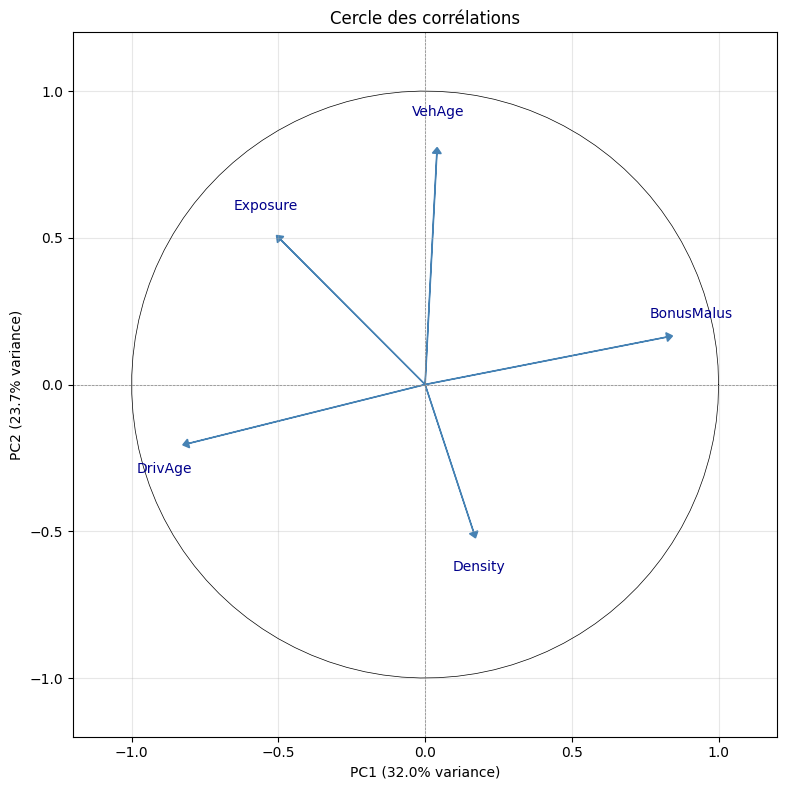

→ Variables proches = corrélées entre elles
→ Variables proches du cercle = bien représentées dans ce plan
→ Variables proches du centre = mal représentées (info dans PC3+)


In [7]:
# =============================================================
# 5. CERCLE DES CORRÉLATIONS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Cercle des corrélations")
print("=" * 60)

# TODO : Tracer le cercle des corrélations (projection des variables 
# originales dans le plan PC1-PC2)
# 
# Formule : correlation de la variable j avec PCk = loading_jk * sqrt(eigenvalue_k) / std(variable_j)
# Mais comme on a standardisé, std=1, donc : corr_jk = loading_jk * sqrt(eigenvalue_k)
#
# Étapes :
# 1. Calculer les corrélations
# 2. Tracer un cercle unité
# 3. Tracer les flèches pour chaque variable
# 4. Annoter avec les noms de variables

# Corrélation variable-composante = loading * sqrt(eigenvalue)
sqrt_eigenvalues = np.sqrt(pca.explained_variance_)
correlations = loadings.values * sqrt_eigenvalues[np.newaxis, :]
corr_df = pd.DataFrame(correlations, index=features,
                       columns=[f'PC{i+1}' for i in range(len(features))])

fig, ax = plt.subplots(figsize=(8, 8))

# Cercle unité
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=0.5)

# Flèches pour chaque variable
for i, feat in enumerate(features):
    ax.arrow(0, 0, corr_df.iloc[i, 0], corr_df.iloc[i, 1],
             head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    offset = 0.05 if corr_df.iloc[i, 1] >= 0 else -0.08
    ax.text(corr_df.iloc[i, 0] * 1.1, corr_df.iloc[i, 1] * 1.1 + offset,
            feat, fontsize=10, ha='center', color='darkblue')

ax.axhline(0, color='grey', linestyle='--', linewidth=0.5)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Cercle des corrélations')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cercle_correlations.png", dpi=150)
plt.show()

print("→ Variables proches = corrélées entre elles")
print("→ Variables proches du cercle = bien représentées dans ce plan")
print("→ Variables proches du centre = mal représentées (info dans PC3+)")



PARTIE 5 : Projection des individus


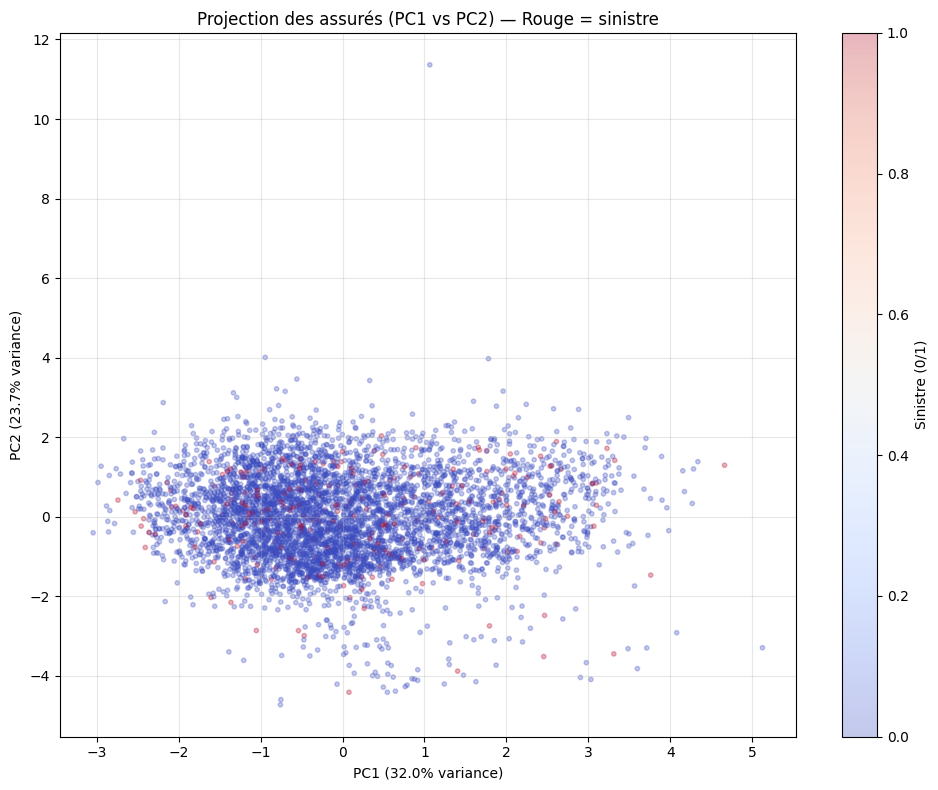

In [8]:
# =============================================================
# 6. PROJECTION DES INDIVIDUS
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Projection des individus")
print("=" * 60)

# TODO : Projeter les assurés dans le plan PC1-PC2
# Colorer les points par une variable catégorielle (ex: ClaimNb > 0 vs ClaimNb == 0)
# Les assurés avec sinistre se distinguent-ils visuellement ?

fig, ax = plt.subplots(figsize=(10, 8))

has_claim = df['ClaimNb'] > 0
n_sample = 5000  # Sous-échantillon pour la lisibilité

np.random.seed(42)
idx = np.random.choice(len(X_pca), n_sample, replace=False)

scatter = ax.scatter(
    X_pca[idx, 0], X_pca[idx, 1],
    c=has_claim.values[idx].astype(int),
    cmap='coolwarm', alpha=0.3, s=10
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Projection des assurés (PC1 vs PC2) — Rouge = sinistre')
plt.colorbar(scatter, label='Sinistre (0/1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("projection_individus.png", dpi=150)
plt.show()



# QUESTION : L'ACP permet-elle de séparer les "bons" des "mauvais" risques ?
# Si non, pourquoi ? (rappel : l'ACP est non supervisée)

## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Pourquoi la standardisation est-elle obligatoire ici ?
   Que se passe-t-il si on fait l'ACP sur les données brutes ?
   --> Sans standardisation, Density (10^1 à 10^5) dominerait TOUTE la variance.
   PC1 serait simplement "Density" → aucun intérêt. La standardisation
   donne un poids égal à chaque variable.

2. Avec 5 variables, l'ACP est-elle vraiment utile ?
   À partir de combien de variables l'ACP devient-elle indispensable ?
   --> Avec 5 variables, l'ACP est surtout pédagogique. Elle devient vraiment
   utile à partir de ~15-20 variables (variables géographiques, croisements,
   embeddings). En tarification moderne avec one-hot encoding, on peut
   facilement avoir 50+ colonnes → ACP indispensable pour la visualisation.

3. PC1 est-il corrélé avec la fréquence sinistre ?
   Que cela signifie-t-il pour un usage en tarification ?
   --> PC1 n'est généralement PAS fortement corrélé avec la sinistralité.
   Normal : l'ACP cherche la variance TOTALE, pas la variance liée à Y.
   Pour un axe lié à Y → utiliser PLS ou supervised feature selection.

4. Si vous ajoutiez les coordonnées géographiques (latitude, longitude),
   comment cela modifierait-il les composantes principales ?
   --> Latitude/longitude ajouteraient un "axe géographique" (probablement
   corrélé avec Density). Si la géographie est un facteur important du
   portefeuille, elle pourrait devenir PC1 ou PC2.

5. En quoi le cercle des corrélations aide-t-il à détecter des 
   redondances entre variables tarifaires ?
   --> Des variables proches sur le cercle des corrélations sont redondantes
   (elles portent la même information). Ex: si DrivAge et BonusMalus
   sont quasi-colinéaires, on pourrait n'en garder qu'une ou utiliser
   le score PC1 comme variable synthétique de "risque".
"""